In [5]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"
import csv 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('help - lc_wise-toi-6 (2).csv')

In [9]:
def augment_value(value):
    flux = 10**(-0.4 * (value - 17.8)) 				
    return flux

In [11]:
df['flux'] = df['mags'].apply(augment_value)

In [13]:
print(df['flux'])

0       91.046071
1       98.121038
2       88.243503
3       85.830212
4       81.136762
          ...    
308    153.483568
309    145.738189
310    153.311030
311    145.613335
312    146.177903
Name: flux, Length: 313, dtype: float64


In [15]:
df['error'] = df['magerrs'].apply(augment_value)
new_df = df.drop(['mags', 'magerrs'], axis=1)

In [17]:
new_df.rename(columns={'jds': 'time'}, inplace=True)

In [19]:
new_df.to_csv('awesome_data.txt', index=False)

In [21]:
print(new_df.isna().sum())  # Shows if there are any missing values
print((new_df == float('inf')).sum())  # Check for infinite values

time     0
flux     0
error    0
dtype: int64
time     0
flux     0
error    0
dtype: int64


In [23]:
print(df.head())

           jds       mags   magerrs       flux         error
0  2458423.811  12.901847  0.090107  91.046071  1.213269e+07
1  2458424.799  12.820595  0.167682  98.121038  1.129606e+07
2  2458425.809  12.935793  0.120141  88.243503  1.180167e+07
3  2458426.797  12.965900  0.167290  85.830212  1.130015e+07
4  2458428.804  13.026956  0.095911  81.136762  1.206801e+07


In [25]:
print(df.describe())

                jds        mags     magerrs        flux         error
count  3.130000e+02  313.000000  313.000000  313.000000  3.130000e+02
mean   2.459139e+06   12.926737    0.142334  114.607338  1.160842e+07
std    4.220094e+02    0.755362    0.097581  102.003716  1.006240e+06
min    2.458424e+06   10.585788    0.009481   23.230249  9.448632e+06
25%    2.458805e+06   12.480922    0.066807   46.739372  1.083698e+07
50%    2.459179e+06   12.691079    0.097895  110.552482  1.204598e+07
75%    2.459516e+06   13.625793    0.212730  134.162546  1.239588e+07
max    2.459907e+06   14.384865    0.361578  768.572144  1.306795e+07


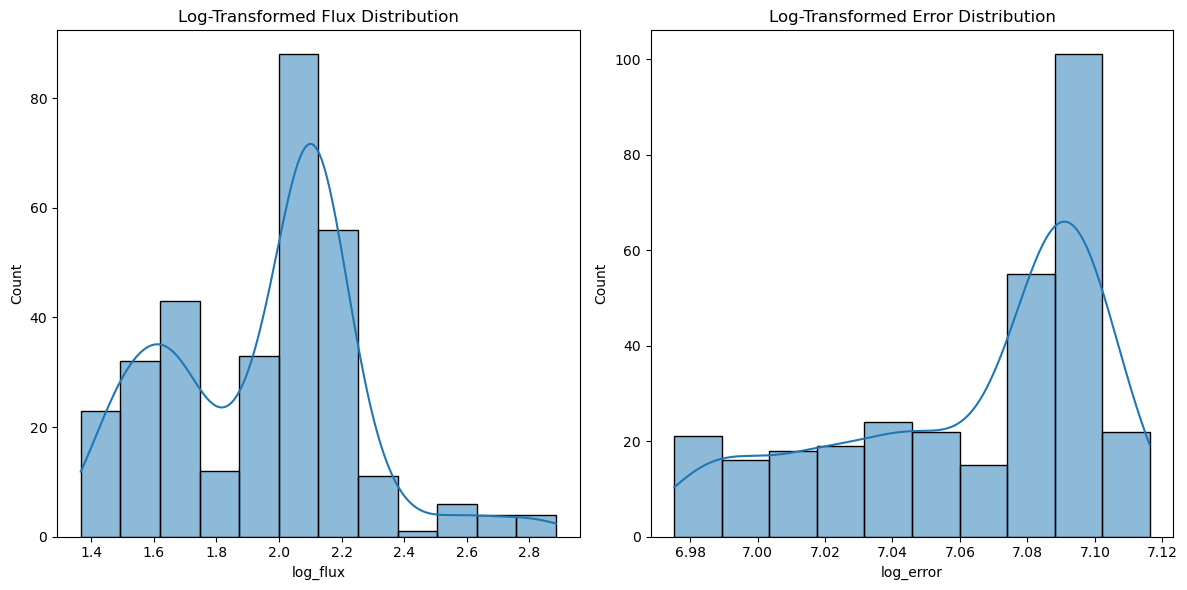

In [35]:
import seaborn as sns

# Apply a logarithmic transformation (use log10 for ease)
new_df['log_flux'] = np.log10(new_df['flux'] + 1e-10)  # Adding small constant to avoid log(0)
new_df['log_error'] = np.log10(new_df['error'] + 1e-10)

# Plot histograms of the transformed data
plt.figure(figsize=(12, 6))

# Log-flux histogram
plt.subplot(1, 2, 1)
sns.histplot(new_df['log_flux'], kde=True)
plt.title('Log-Transformed Flux Distribution')

# Log-error histogram
plt.subplot(1, 2, 2)
sns.histplot(new_df['log_error'], kde=True)
plt.title('Log-Transformed Error Distribution')

plt.tight_layout()
plt.show()

In [37]:
print("Original flux and error statistics:")
print(new_df[['flux', 'error']].describe())

print("\nLog-transformed flux and error statistics:")
print(new_df[['log_flux', 'log_error']].describe())

Original flux and error statistics:
             flux         error
count  313.000000  3.130000e+02
mean   114.607338  1.160842e+07
std    102.003716  1.006240e+06
min     23.230249  9.448632e+06
25%     46.739372  1.083698e+07
50%    110.552482  1.204598e+07
75%    134.162546  1.239588e+07
max    768.572144  1.306795e+07

Log-transformed flux and error statistics:
         log_flux   log_error
count  313.000000  313.000000
mean     1.949305    7.063067
std      0.302145    0.039032
min      1.366054    6.975369
25%      1.669683    7.034908
50%      2.043568    7.080842
75%      2.127631    7.093277
max      2.885685    7.116208


In [53]:
df = new_df.drop(['flux', 'error'], axis=1)
df.rename(columns={'log_flux':'flux'}, inplace=True)
df.rename(columns={'log_error':'error'}, inplace=True)

df.to_csv('data.csv', index=False)